In [3]:
import numpy as np
from PIL import Image

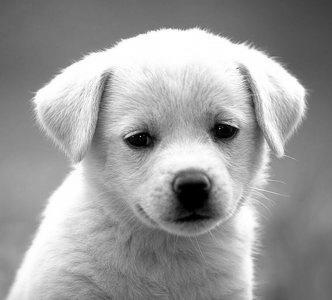

In [4]:
img = Image.open("dog.jpg")
img


In [5]:
img_array = np.array(img)
img_array

array([[[ 89,  89,  89],
        [ 88,  88,  88],
        [ 88,  88,  88],
        ...,
        [ 61,  61,  61],
        [ 61,  61,  61],
        [ 60,  60,  60]],

       [[ 89,  89,  89],
        [ 89,  89,  89],
        [ 88,  88,  88],
        ...,
        [ 61,  61,  61],
        [ 61,  61,  61],
        [ 60,  60,  60]],

       [[ 90,  90,  90],
        [ 89,  89,  89],
        [ 89,  89,  89],
        ...,
        [ 61,  61,  61],
        [ 61,  61,  61],
        [ 61,  61,  61]],

       ...,

       [[144, 144, 144],
        [144, 144, 144],
        [145, 145, 145],
        ...,
        [103, 103, 103],
        [103, 103, 103],
        [102, 102, 102]],

       [[144, 144, 144],
        [144, 144, 144],
        [147, 147, 147],
        ...,
        [103, 103, 103],
        [103, 103, 103],
        [102, 102, 102]],

       [[144, 144, 144],
        [145, 145, 145],
        [149, 149, 149],
        ...,
        [103, 103, 103],
        [103, 103, 103],
        [102, 102, 102]]

In [6]:
img_array.dtype

dtype('uint8')

In [7]:
img_array = img_array.astype(np.float32)

In [8]:
noise = np.random.normal(0,15,img_array.shape)

In [9]:
noisy_img = img_array + noise

In [10]:
noisy_img = np.clip(noisy_img, 0, 255)


In [11]:
noisy_img = noisy_img.astype(np.uint8)


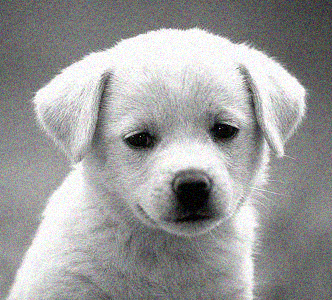

In [12]:
noisy_image = Image.fromarray(noisy_img)
noisy_image


In [13]:
noisy_image.save("noisy_dog.jpg")

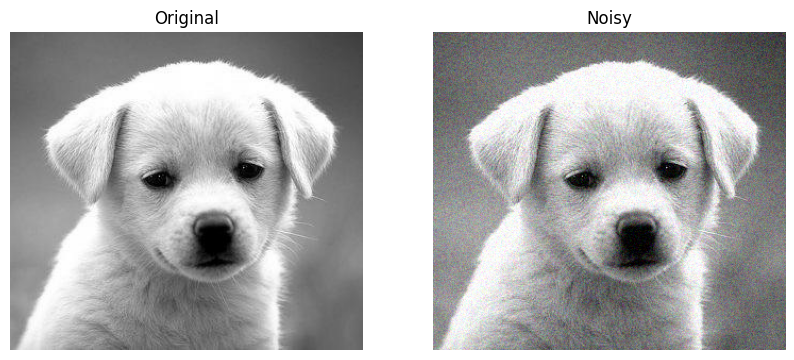

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Noisy")
plt.imshow(noisy_image, cmap='gray')
plt.axis('off')

plt.show()

QUESTION 2

In [1]:
import matplotlib.pyplot as plt


In [17]:
img = Image.open("dog.jpg").convert("L")
image = np.array(img).astype(np.float32)
image.shape


(300, 332)

In [18]:
kernel = np.array([[1,0,-1],
                   [2,0,-2],
                   [1,0,-1]])
flipped_kernel = np.flipud(np.fliplr(kernel))


In [19]:
padded = np.pad(image, ((1,1),(1,1)), mode = 'constant', constant_values = 0)

In [20]:
h, w = image.shape
output = np.zeros_like(image, dtype=np.float32)

for i in range(h):
    for j in range(w):
        patch = padded[i:i+3, j:j+3]
        output[i, j] = np.sum(patch * flipped_kernel)

In [21]:
output = np.abs(output)

output = np.clip(output, 0, 255)


output = output.astype(np.uint8)

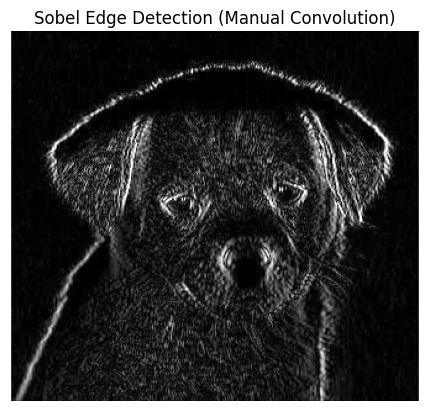

In [22]:
plt.imshow(output, cmap='gray')
plt.title("Sobel Edge Detection (Manual Convolution)")
plt.axis('off')
plt.show()

Question 3

In [23]:
img = Image.open("dog.jpg")
image = np.array(img).astype(np.float32)


In [24]:
H, W, C = image.shape

In [25]:
size = 7
sigma = 1.0
k = size // 2

# Gaussian kernel
x = np.arange(-k, k+1)
y = np.arange(-k, k+1)
x, y = np.meshgrid(x, y)

In [26]:
kernel = (1/(2*np.pi*sigma**2)) * np.exp(-(x**2 + y**2)/(2*sigma**2))
kernel = kernel / np.sum(kernel)

In [27]:
kernel = np.flipud(np.fliplr(kernel))

In [28]:
padded = np.pad(image, ((k,k),(k,k),(0,0)), mode='constant')

In [29]:
output = np.zeros((H, W, C), dtype=np.float32)

In [30]:
for c in range(C):
    for i in range(H):
        for j in range(W):
            patch = padded[i:i+size, j:j+size, c]
            output[i,j,c] = np.sum(patch * kernel)

In [31]:
output = np.clip(output, 0, 255).astype(np.uint8)


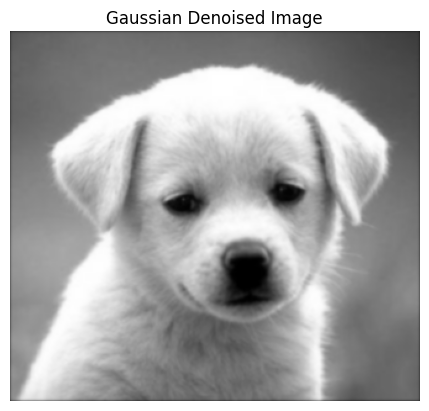

In [32]:
plt.imshow(output)
plt.title("Gaussian Denoised Image")
plt.axis('off')
plt.show()

In [33]:
sharpening_kernel = np.array([
    [1, 4, 6, 4, 1],
    [4, 16, 24, 16, 4],
    [6, 24, -476, 24, 6],
    [4, 16, 24, 16, 4],
    [1, 4, 6, 4, 1]
], dtype=np.float32) * (-1.0 / 256.0)

In [34]:
sharpening_kernel = np.flipud(np.fliplr(sharpening_kernel))


In [35]:
k2 = 5 // 2

padded = np.pad(output.astype(np.float32), ((k2,k2),(k2,k2),(0,0)), mode='constant')

sharp = np.zeros((H, W, C), dtype=np.float32)

In [36]:
for c in range(C):
    for i in range(H):
        for j in range(W):
            patch = padded[i:i+5, j:j+5, c]
            sharp[i,j,c] = np.sum(patch * sharpening_kernel)

sharp = np.clip(sharp, 0, 255).astype(np.uint8)

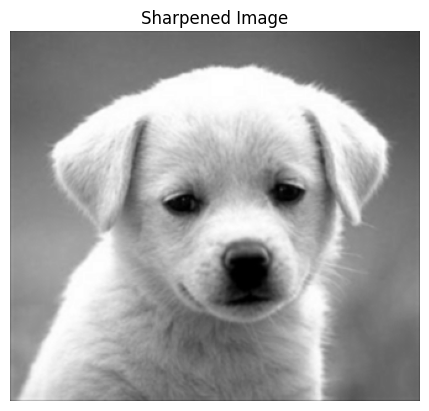

In [37]:
plt.imshow(sharp)
plt.title("Sharpened Image")
plt.axis('off')
plt.show()

Question 4

In [38]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

shelf = np.array(Image.open("shelf.jpg")).astype(np.float32)
template = np.array(Image.open("template.jpg")).astype(np.float32)

Hs, Ws, Cs = shelf.shape
Ht, Wt, Ct = template.shape

In [39]:
template_c = template - np.mean(template)
template_flipped = np.flip(template_c, axis=(0,1))

result_conv = np.zeros((Hs - Ht + 1, Ws - Wt + 1))

for i in range(Hs - Ht + 1):
    for j in range(Ws - Wt + 1):
        patch = shelf[i:i+Ht, j:j+Wt, :]
        patch = patch - np.mean(patch)

        result_conv[i, j] = np.sum(patch * template_flipped)

y_conv, x_conv = np.unravel_index(np.argmax(result_conv), result_conv.shape)

print("Convolution match:", y_conv, x_conv)

Convolution match: 170 431


In [40]:
template_corr = template - np.mean(template)

result_corr = np.zeros((Hs - Ht + 1, Ws - Wt + 1))

for i in range(Hs - Ht + 1):
    for j in range(Ws - Wt + 1):
        patch = shelf[i:i+Ht, j:j+Wt, :]
        patch = patch - np.mean(patch)

        result_corr[i, j] = np.sum(patch * template_corr)

y_corr, x_corr = np.unravel_index(np.argmax(result_corr), result_corr.shape)

print("Correlation match:", y_corr, x_corr)

Correlation match: 8 41


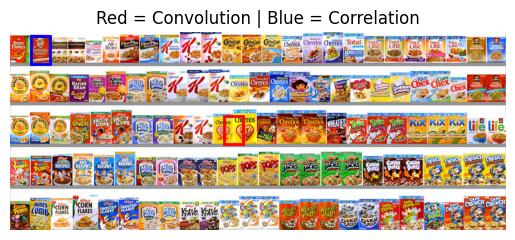

In [41]:
plt.imshow(shelf.astype(np.uint8))

# convolution (red)
plt.gca().add_patch(
    plt.Rectangle((x_conv, y_conv), Wt, Ht,
                  edgecolor='red', fill=False, linewidth=2)
)

# correlation (blue)
plt.gca().add_patch(
    plt.Rectangle((x_corr, y_corr), Wt, Ht,
                  edgecolor='blue', fill=False, linewidth=2)
)

plt.title("Red = Convolution | Blue = Correlation")
plt.axis('off')
plt.show()

PART E:
Correlation is more accurate because it preserves the original orientation of the template. Convolution flips the template, which can distort the matching when the object orientation matters, leading to less accurate localization.

PART F:
Both convolution and correlation have the same computational complexity [O(N.M.k^2)]However, correlation is slightly more efficient in practice since it does not require flipping the template, making implementation simpler.

PART G:
Correlation is better suited for template matching because it directly compares the template with image regions without altering its structure. This makes it ideal when detecting exact object appearances. Convolution is more suitable for feature extraction tasks like edge detection rather than direct matching

PART H:
From the results, correlation provides a more accurate and visually correct localization of the product on the shelf. Convolution may still detect a similar region, but due to template flipping, it is less reliable. Therefore, correlation is more effective for this task.